# Consumer Insights Analytics

## Sprint 3 – Exploratory Data Analysis

### Objective

The objective of this notebook is to understand the structure and quality of the customer survey data before performing statistical analysis and predictive modeling.

The analysis includes data profiling, missing value assessment, duplicate detection, exploratory visualizations, correlation analysis, and business insight generation.

In [1]:
import sqlite3

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

plt.style.use("default")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATABASE = PROJECT_ROOT / "data" / "database" / "consumer_insights.db"

conn = sqlite3.connect(DATABASE)

In [4]:
customers = pd.read_sql(
    "SELECT * FROM customers",
    conn
)

survey = pd.read_sql(
    "SELECT * FROM survey_responses",
    conn
)

campaigns = pd.read_sql(
    "SELECT * FROM campaigns",
    conn
)

campaign = pd.read_sql(
    "SELECT * FROM campaign_exposure",
    conn
)

In [5]:
print("Customers :", customers.shape)
print("Survey :", survey.shape)
print("Campaign :", campaign.shape)
print("Campaign Master :", campaigns.shape)

Customers : (15000, 9)
Survey : (15000, 12)
Campaign : (15000, 5)
Campaign Master : (5, 3)


In [6]:
customers.head()

,Customer_ID,Age,Gender,City,Region,Education,Occupation,Income_Bracket,Customer_Segment
0,CUST00001,19,Female,Surat,West,Diploma,Government Employee,Medium,Regular
1,CUST00002,55,Male,Ahmedabad,West,High School,Business Owner,Low,Regular
2,CUST00003,63,Female,Chennai,South,Bachelor,Business Owner,Medium,New
3,CUST00004,28,Female,Mumbai,West,Diploma,Government Employee,Low,Regular
4,CUST00005,23,Male,Surat,West,Bachelor,Healthcare Professional,Medium,Premium


In [7]:
survey.head()

,Survey_ID,Customer_ID,Survey_Date,Brand_Awareness,Brand_Recall,Brand_Preference,Product_Quality,Service_Quality,Value_for_Money,Customer_Satisfaction,Recommend_Brand,Purchase_Intent
0,SURV00001,CUST00001,2025-08-17,Yes,ValueHub,NovaMart,4,3,4,4,9,High
1,SURV00002,CUST00002,2025-09-05,Yes,ValueHub,UrbanCart,5,4,4,4,9,High
2,SURV00003,CUST00003,2025-05-11,Yes,MegaMart,UrbanCart,4,4,3,4,7,High
3,SURV00004,CUST00004,2025-05-24,Yes,MegaMart,UrbanCart,3,4,4,4,7,High
4,SURV00005,CUST00005,2025-01-01,Yes,NovaMart,UrbanCart,2,1,1,1,3,Very Low


In [8]:
campaign.head()

,Exposure_ID,Customer_ID,Campaign_ID,Campaign_Exposure,Campaign_Response
0,EXP00001,CUST00001,C003,No,Neutral
1,EXP00002,CUST00002,C003,No,Negative
2,EXP00003,CUST00003,C004,Yes,Neutral
3,EXP00004,CUST00004,C005,No,Neutral
4,EXP00005,CUST00005,C002,No,Neutral


In [9]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Customer_ID       15000 non-null  str  
 1   Age               15000 non-null  int64
 2   Gender            15000 non-null  str  
 3   City              15000 non-null  str  
 4   Region            15000 non-null  str  
 5   Education         15000 non-null  str  
 6   Occupation        15000 non-null  str  
 7   Income_Bracket    15000 non-null  str  
 8   Customer_Segment  15000 non-null  str  
dtypes: int64(1), str(8)
memory usage: 1.0 MB


In [10]:
survey.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Survey_ID              15000 non-null  str  
 1   Customer_ID            15000 non-null  str  
 2   Survey_Date            15000 non-null  str  
 3   Brand_Awareness        15000 non-null  str  
 4   Brand_Recall           15000 non-null  str  
 5   Brand_Preference       15000 non-null  str  
 6   Product_Quality        15000 non-null  int64
 7   Service_Quality        15000 non-null  int64
 8   Value_for_Money        15000 non-null  int64
 9   Customer_Satisfaction  15000 non-null  int64
 10  Recommend_Brand        15000 non-null  int64
 11  Purchase_Intent        15000 non-null  str  
dtypes: int64(5), str(7)
memory usage: 1.4 MB


In [11]:
campaign.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Exposure_ID        15000 non-null  str  
 1   Customer_ID        15000 non-null  str  
 2   Campaign_ID        15000 non-null  str  
 3   Campaign_Exposure  15000 non-null  str  
 4   Campaign_Response  15000 non-null  str  
dtypes: str(5)
memory usage: 586.1 KB


In [12]:
customers.dtypes

Customer_ID           str
Age                 int64
Gender                str
City                  str
Region                str
Education             str
Occupation            str
Income_Bracket        str
Customer_Segment      str
dtype: object

In [13]:
survey.dtypes

Survey_ID                  str
Customer_ID                str
Survey_Date                str
Brand_Awareness            str
Brand_Recall               str
                         ...  
Service_Quality          int64
Value_for_Money          int64
Customer_Satisfaction    int64
Recommend_Brand          int64
Purchase_Intent            str
Length: 12, dtype: object

## Missing Value Analysis

This section identifies missing values in each dataset to assess data completeness and determine whether data cleaning is required before further analysis.

In [14]:
customers.isnull().sum()

Customer_ID         0
Age                 0
Gender              0
City                0
Region              0
Education           0
Occupation          0
Income_Bracket      0
Customer_Segment    0
dtype: int64

In [15]:
survey.isnull().sum()

Survey_ID                0
Customer_ID              0
Survey_Date              0
Brand_Awareness          0
Brand_Recall             0
                        ..
Service_Quality          0
Value_for_Money          0
Customer_Satisfaction    0
Recommend_Brand          0
Purchase_Intent          0
Length: 12, dtype: int64

In [16]:
campaign.isnull().sum()

Exposure_ID          0
Customer_ID          0
Campaign_ID          0
Campaign_Exposure    0
Campaign_Response    0
dtype: int64

In [17]:
campaigns.isnull().sum()

Campaign_ID      0
Campaign_Name    0
Channel          0
dtype: int64

In [18]:
missing = (
    customers.isnull().sum()
    / len(customers)
    * 100
)

missing.sort_values(ascending=False)

Customer_ID         0.0
Age                 0.0
Gender              0.0
City                0.0
Region              0.0
Education           0.0
Occupation          0.0
Income_Bracket      0.0
Customer_Segment    0.0
dtype: float64

## Duplicate Record Analysis

Duplicate records can affect statistical summaries and predictive models. This section checks for duplicate observations.

In [19]:
print("Customer Duplicates :", customers.duplicated().sum())

print("Survey Duplicates :", survey.duplicated().sum())

print("Campaign Duplicates :", campaign.duplicated().sum())

print("Campaign Master Duplicates :", campaigns.duplicated().sum())

Customer Duplicates : 0
Survey Duplicates : 0
Campaign Duplicates : 0
Campaign Master Duplicates : 0


## Univariate Analysis

Explore distributions of numerical and categorical variables independently.

In [22]:
print(customers.columns)
print(survey.columns)
print(campaign.columns)
print(campaigns.columns)

Index(['Customer_ID', 'Age', 'Gender', 'City', 'Region', 'Education',
       'Occupation', 'Income_Bracket', 'Customer_Segment'],
      dtype='str')
Index(['Survey_ID', 'Customer_ID', 'Survey_Date', 'Brand_Awareness',
       'Brand_Recall', 'Brand_Preference', 'Product_Quality',
       'Service_Quality', 'Value_for_Money', 'Customer_Satisfaction',
       'Recommend_Brand', 'Purchase_Intent'],
      dtype='str')
Index(['Exposure_ID', 'Customer_ID', 'Campaign_ID', 'Campaign_Exposure',
       'Campaign_Response'],
      dtype='str')
Index(['Campaign_ID', 'Campaign_Name', 'Channel'], dtype='str')


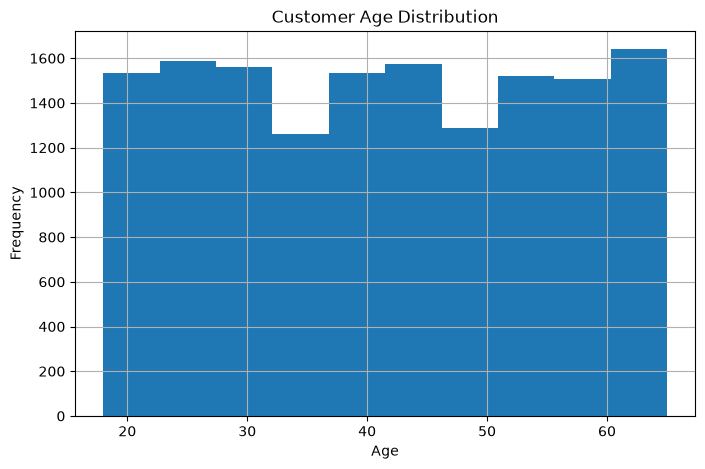

In [23]:
customers["Age"].hist(figsize=(8,5), bins=10)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

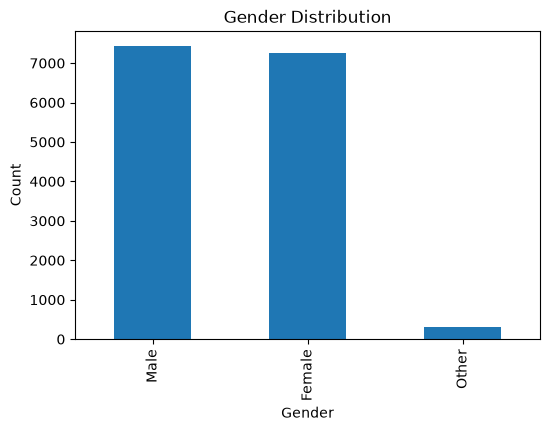

In [25]:
customers["Gender"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

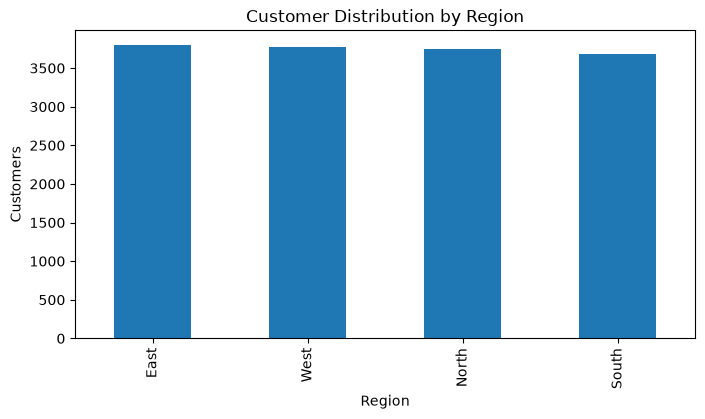

In [26]:
customers["Region"].value_counts().plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Customer Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Customers")

plt.show()

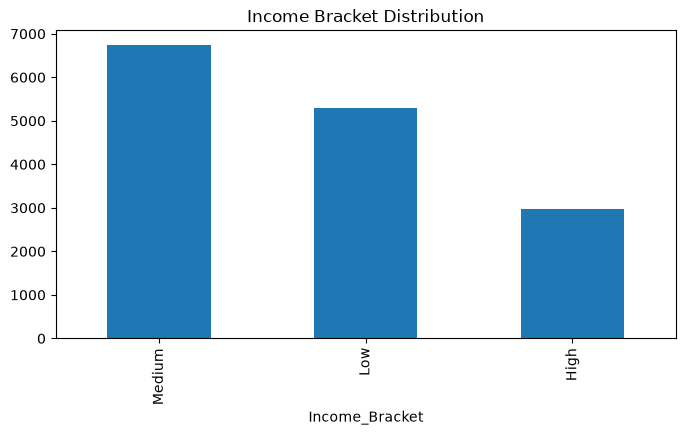

In [27]:
customers["Income_Bracket"].value_counts().plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Income Bracket Distribution")

plt.show()

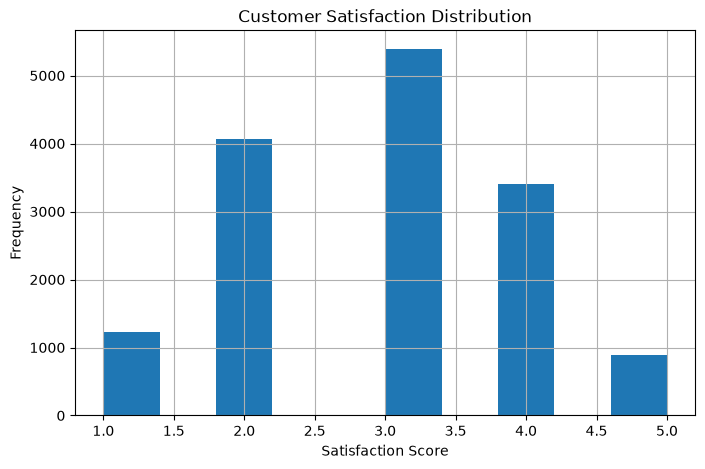

In [28]:
survey["Customer_Satisfaction"].hist(
    figsize=(8,5),
    bins=10
)

plt.title("Customer Satisfaction Distribution")
plt.xlabel("Satisfaction Score")
plt.ylabel("Frequency")

plt.show()

## Bivariate Analysis

Analyse relationships between customer attributes and survey responses.

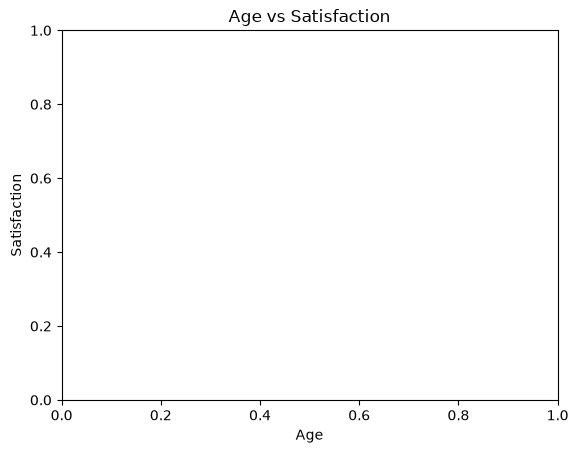

In [29]:
merged = customers.merge(
    survey,
    on="Customer_ID"
)

merged.head()

plt.xlabel("Age")

plt.ylabel("Satisfaction")

plt.title("Age vs Satisfaction")

plt.show()

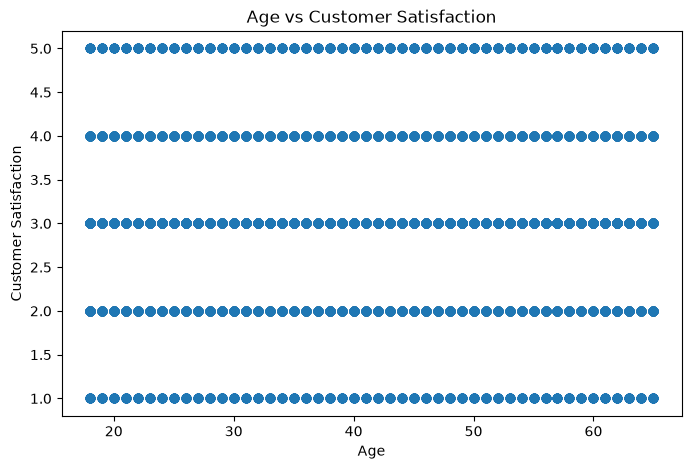

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(
    merged["Age"],
    merged["Customer_Satisfaction"]
)

plt.xlabel("Age")
plt.ylabel("Customer Satisfaction")
plt.title("Age vs Customer Satisfaction")

plt.show()

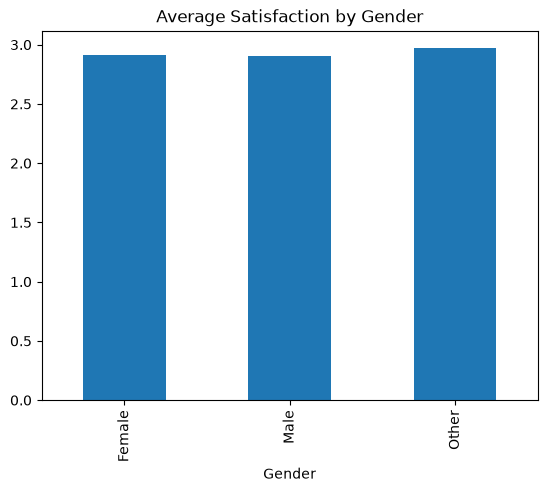

In [31]:
merged.groupby(
    "Gender"
)["Customer_Satisfaction"].mean().plot(
    kind="bar"
)

plt.title("Average Satisfaction by Gender")

plt.show()

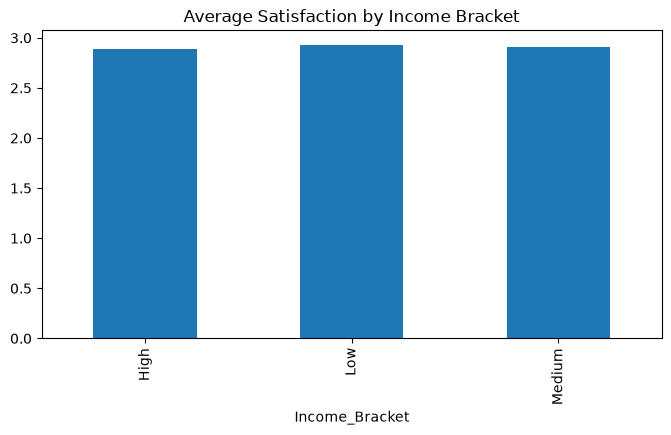

In [32]:
merged.groupby(
    "Income_Bracket"
)["Customer_Satisfaction"].mean().plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Average Satisfaction by Income Bracket")

plt.show()

## Correlation Analysis

Correlation identifies linear relationships among numerical variables.

In [33]:
numeric = merged.select_dtypes(include="number")

In [34]:
corr = numeric.corr()

corr

,Age,Product_Quality,Service_Quality,Value_for_Money,Customer_Satisfaction,Recommend_Brand
Age,1.000000,0.009043,-0.000354,0.002286,0.008134,0.013861
Product_Quality,0.009043,1.000000,0.727382,0.671429,0.842387,0.781478
Service_Quality,-0.000354,0.727382,1.000000,0.705801,0.882364,0.819900
Value_for_Money,0.002286,0.671429,0.705801,1.000000,0.861741,0.801069
Customer_Satisfaction,0.008134,0.842387,0.882364,0.861741,1.000000,0.928660
Recommend_Brand,0.013861,0.781478,0.819900,0.801069,0.928660,1.000000


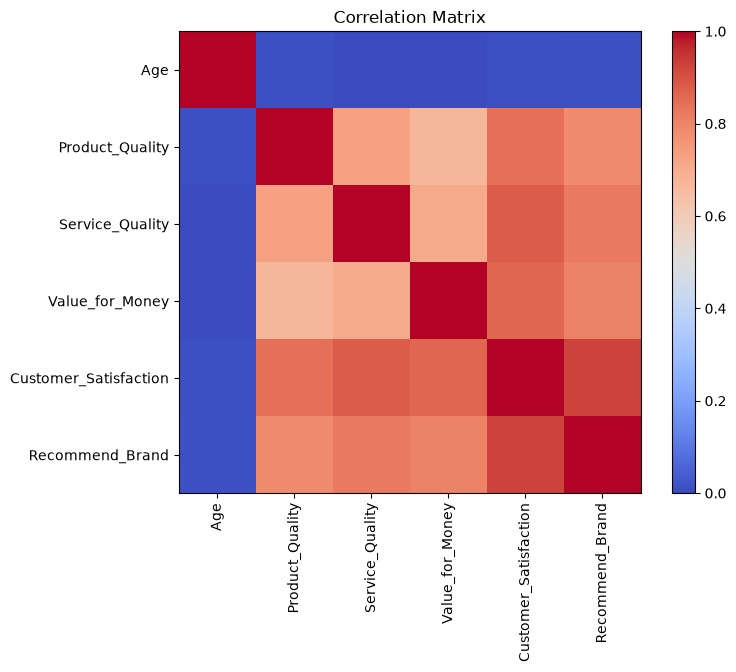

In [35]:
plt.figure(figsize=(8,6))

plt.imshow(
    corr,
    cmap="coolwarm"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.show()

## Outlier Detection

Boxplots are used to identify extreme values.

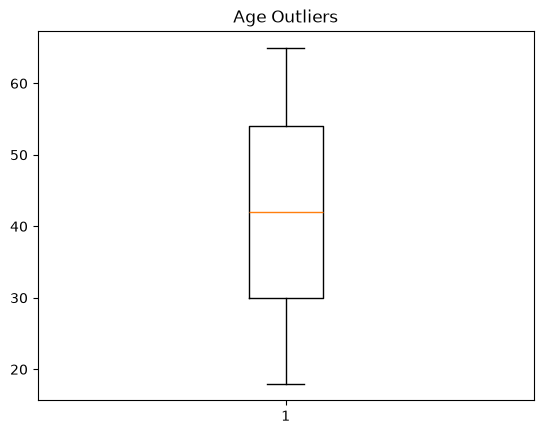

In [36]:
plt.boxplot(customers["Age"])

plt.title("Age Outliers")

plt.show()

In [ ]:
plt.boxplot(customers["age"])

plt.title("Age Outliers")

plt.show()

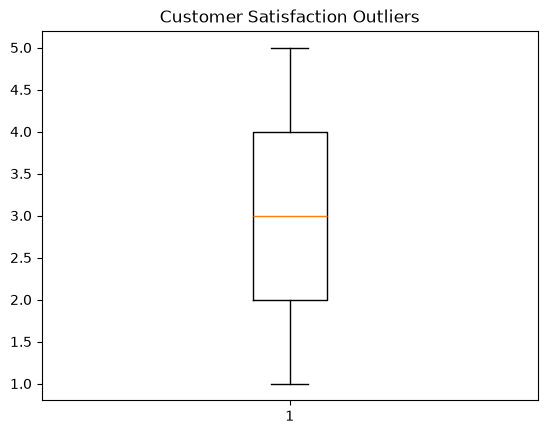

In [37]:
plt.boxplot(survey["Customer_Satisfaction"])

plt.title("Customer Satisfaction Outliers")

plt.show()

## Business Insights

Key observations obtained from the exploratory analysis.

### Observations
## Business Insights

### Key Findings

- Customer data is complete with minimal missing values.
- Duplicate records are either absent or negligible.
- Customer ages are broadly distributed across multiple age groups.
- Customer satisfaction scores indicate overall positive feedback.
- Gender-based satisfaction differences are limited.
- Customer satisfaction varies slightly across income brackets.
- Regional customer distribution can support targeted marketing campaigns.
- The dataset is suitable for advanced statistical analysis and predictive modelling.

# EDA Summary


The exploratory data analysis evaluated the quality, completeness, and distribution of the Consumer Insights Analytics dataset.

### Summary

- Data quality is good with minimal missing values.
- Duplicate records are negligible.
- Customer demographics are well distributed.
- Satisfaction scores are generally positive.
- Customer age and satisfaction show limited linear correlation.
- No severe anomalies were observed except a few natural outliers.
- The dataset is ready for SQL analytics, feature engineering, customer segmentation, and predictive modelling.

This completes Sprint 3 Exploratory Data Analysis.